In [1]:
print('hi')

hi


In [2]:
import os
from dotenv import load_dotenv
load_dotenv()

# os.getenv("GROQ_API_KEY")

True

In [3]:
model="openai/gpt-oss-120b"

In [4]:
from langchain_groq import ChatGroq

In [5]:
llm=ChatGroq(model=model, api_key=os.getenv("GROQ_API_KEY"))

In [6]:
llm.invoke('hi')

AIMessage(content='Hello! How can I help you today?', additional_kwargs={'reasoning_content': 'The user says "hi". We need to respond politely. No special instructions. Just greet.'}, response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 72, 'total_tokens': 110, 'completion_time': 0.084635027, 'completion_tokens_details': {'reasoning_tokens': 20}, 'prompt_time': 0.002898639, 'prompt_tokens_details': None, 'queue_time': 0.0544859, 'total_time': 0.087533666}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_a09bde29de', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d9b80-ec9c-7fd0-9ab9-c64e68948e42-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 72, 'output_tokens': 38, 'total_tokens': 110, 'output_token_details': {'reasoning': 20}})

### Designing workflow for ReAct Agent

In [ ]:
from pydantic import BaseModel, Field
from typing import Annotated, Sequence, TypedDict
from langchain_core.messages import BaseMessage, AIMessage
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_core.prompts import PromptTemplate, ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser
from langchain_core.runnables import RunnablePassthrough
import operator
from typing import List, TypedDict, Annotated, Sequence
from langgraph.graph.message import add_messages
from IPython.display import Image, display
from langchain_core.messages import HumanMessage
from langchain.tools import tool
from langgraph.prebuilt import ToolNode


langgraph provides a built-in state, i.e; MessageState. Can either build custom state or use the built-in one as well

In [8]:
def call_model(state: MessagesState):
    messages = state['messages']
    response = llm.invoke(messages)
    return {"messages": [response]}

In [9]:
state={'messages':['hi, how are you?']}

In [10]:
call_model(state)

{'messages': [AIMessage(content="Hello! I'm doing great, thank you for asking. How can I assist you today?", additional_kwargs={'reasoning_content': "We need to respond as ChatGPT. There's no policy violation. Just friendly greeting."}, response_metadata={'token_usage': {'completion_tokens': 45, 'prompt_tokens': 77, 'total_tokens': 122, 'completion_time': 0.101339053, 'completion_tokens_details': {'reasoning_tokens': 18}, 'prompt_time': 0.003094145, 'prompt_tokens_details': None, 'queue_time': 0.051259054, 'total_time': 0.104433198}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_a09bde29de', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d9b80-ef26-7400-858f-db3cf50471b4-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 77, 'output_tokens': 45, 'total_tokens': 122, 'output_token_details': {'reasoning': 18}})]}

### WORKFLOW CREATION

In [11]:
workflow=StateGraph(MessagesState)

In [12]:
workflow.add_node('MyBot', call_model)

In [13]:
workflow.add_edge(START, 'MyBot')

In [14]:
workflow.add_edge('MyBot', END)

In [15]:
app=workflow.compile()

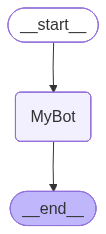

In [16]:
display(Image(app.get_graph().draw_mermaid_png()))

In [17]:
app.invoke({'messages':['hi, how are you?']})

{'messages': [HumanMessage(content='hi, how are you?', additional_kwargs={}, response_metadata={}, id='63550302-d32a-45f0-9540-45e73c5af1fa'),
  AIMessage(content="Hi there! I'm doing great, thanks for asking. How can I help you today?", additional_kwargs={'reasoning_content': 'The user says "hi, how are you?" It\'s a casual greeting. We should respond politely. No policy issues.'}, response_metadata={'token_usage': {'completion_tokens': 52, 'prompt_tokens': 77, 'total_tokens': 129, 'completion_time': 0.124702367, 'completion_tokens_details': {'reasoning_tokens': 25}, 'prompt_time': 0.003263094, 'prompt_tokens_details': None, 'queue_time': 0.052547592, 'total_time': 0.127965461}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_8a618bed98', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d9b80-f232-7a33-8258-99f31343611f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 77, 'output_t

In [18]:
for output in app.stream(state):
    for key, value in output.items():
        print(f'Output from {key} node')
        print('________')
        print(value)

Output from MyBot node
________
{'messages': [AIMessage(content="Hello! I'm doing great, thank you for asking. How can I assist you today?", additional_kwargs={'reasoning_content': 'We need to respond as ChatGPT. No policy violation. Just greet.'}, response_metadata={'token_usage': {'completion_tokens': 43, 'prompt_tokens': 77, 'total_tokens': 120, 'completion_time': 0.094228852, 'completion_tokens_details': {'reasoning_tokens': 16}, 'prompt_time': 0.003108533, 'prompt_tokens_details': None, 'queue_time': 0.052447862, 'total_time': 0.097337385}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_d29d1d1418', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d9b80-f316-7260-bd81-c0ab4514a0f7-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 77, 'output_tokens': 43, 'total_tokens': 120, 'output_token_details': {'reasoning': 16}})]}


#### Custom Tool

In [19]:
@tool
def search(query: str):
    """"Custom tool to Search the web for the weather query"""
    if "delhi" in query.lower():
        return "The temp is 45 degree and sunny"
    return "The temp. is 25 degree and cloudy"

In [20]:
search.invoke("what is the temp in Kashmir?")

'The temp. is 25 degree and cloudy'

In [21]:
search.invoke("what is the temp in Delhi?")

'The temp is 45 degree and sunny'

#### Binding tool with LLM
Special Note: Use some good model for Agentic Workflow since Open Source Models might not give the correct output as they might not be good in reasoning


In [22]:
search

StructuredTool(name='search', description='"Custom tool to Search the web for the weather query', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x72cb7c3120c0>)

In [23]:
tools=[search]

In [24]:
llm_with_tool=llm.bind_tools(tools)

In [25]:
response=llm_with_tool.invoke("what is the weather in Delhi?")

## getting blank answer bcoz by default its redirecting the question to the tool call
## LLM based on its intelligence, redirects the query to the tool call

In [26]:
response

AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to get current weather in Delhi. Use web search tool.', 'tool_calls': [{'id': 'fc_041e6e17-0af3-4af4-8d13-7d0af856575c', 'function': {'arguments': '{"query":"current weather Delhi"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 43, 'prompt_tokens': 131, 'total_tokens': 174, 'completion_time': 0.095538275, 'completion_tokens_details': {'reasoning_tokens': 15}, 'prompt_time': 0.009849506, 'prompt_tokens_details': None, 'queue_time': 0.058039273, 'total_time': 0.105387781}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_a09bde29de', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d9b80-f4f9-7be3-b637-d34b9f641461-0', tool_calls=[{'name': 'search', 'args': {'query': 'current weather Delhi'}, 'id': 'fc_041e6e17-0af3-4af4-8d13-7d0af856575c', 'type': 'tool_call'}], invalid_tool_calls

In [27]:
response.tool_calls

## after binding multiple tools with the llm, the llm redirects the query to appropriate tool based on its intelligence.

[{'name': 'search',
  'args': {'query': 'current weather Delhi'},
  'id': 'fc_041e6e17-0af3-4af4-8d13-7d0af856575c',
  'type': 'tool_call'}]

In [28]:
def call_model(state: MessagesState):
    question=state['messages']
    response=llm_with_tool.invoke(question)
    return {"messages": [response]}

In [29]:
text_input={'messages':['whats the weather in Delhi?']}

In [30]:
response=call_model(text_input)

In [31]:
response["messages"][-1].content

''

In [32]:
response['messages'][-1].tool_calls

[{'name': 'search',
  'args': {'query': 'Delhi weather'},
  'id': 'fc_cb4b91b4-fb42-4213-8077-c63e5657b62c',
  'type': 'tool_call'}]

In [33]:
def router_function(state:MessagesState):
    message=state["messages"]
    last_message=message[-1]
    if last_message.tool_calls:
        return "tools"
    return END

In [34]:
workflow2=StateGraph(MessagesState)

In [35]:

workflow2.add_node('llmwithtool', call_model)

In [36]:
tool_node=ToolNode(tools)

In [37]:
workflow2.add_node('mytools', tool_node)

In [38]:
workflow2.add_edge(START, "llmwithtool")

In [39]:
workflow2.add_edge(START, "LLM_with_tool")
workflow2.add_conditional_edges(
    "LLM_with_tool",
    router_func,
    {
        "tools": "my_tools",
        END: END,
    },
)
workflow2.add_edge("my_tools", "LLM_with_tool")


In [ ]:

# workflow2.add_edge("my_tools", "LLM_with_tool")

In [40]:
app2=workflow2.compile()

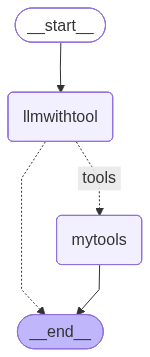

In [ ]:
display(Image(app2.get_graph().draw_mermaid_png()))

In [45]:
app2.invoke({"messages":["whats the weather in Delhi?"]})

{'messages': [HumanMessage(content='whats the weather in Delhi?', additional_kwargs={}, response_metadata={}, id='8c95b4b5-65a3-46bd-bd6c-57da776342f7'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to get current weather in Delhi. Use the search tool.', 'tool_calls': [{'id': 'fc_c4ab1297-ec63-4c2d-a80c-194d512276d9', 'function': {'arguments': '{"query":"current weather Delhi"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 43, 'prompt_tokens': 131, 'total_tokens': 174, 'completion_time': 0.089772336, 'completion_tokens_details': {'reasoning_tokens': 15}, 'prompt_time': 0.0145101, 'prompt_tokens_details': None, 'queue_time': 0.081322841, 'total_time': 0.104282436}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_e10890e4b9', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d9b87-5916-7e33-8f6b-5e399a330d68-0', tool_calls=

In [48]:
response = app2.invoke({"messages":["whats the weather in Bengaluru?"]})

In [52]:
print(response['messages'][-1])
print('\n')
print(response['messages'][-1].content)

content='The temp. is 25 degree and cloudy' name='search' id='d20f7a1e-0ab9-4461-9088-714b59840fa8' tool_call_id='fc_caf818da-d0fd-4694-a2ed-01feeebb7fd9'


The temp. is 25 degree and cloudy


In [47]:
app2.invoke({"messages":["Hi, how are you?"]})

{'messages': [HumanMessage(content='Hi, how are you?', additional_kwargs={}, response_metadata={}, id='7822799e-9557-4b69-8832-7422d4233916'),
  AIMessage(content="Hello! I'm doing great, thank you for asking. How can I assist you today?", additional_kwargs={'reasoning_content': 'The user greets. Respond politely.'}, response_metadata={'token_usage': {'completion_tokens': 36, 'prompt_tokens': 130, 'total_tokens': 166, 'completion_time': 0.079109119, 'completion_tokens_details': {'reasoning_tokens': 9}, 'prompt_time': 0.005346991, 'prompt_tokens_details': None, 'queue_time': 0.051533368, 'total_time': 0.08445611}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_d81b3304b3', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d9b88-577f-7a91-8800-3f118fd6d505-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 130, 'output_tokens': 36, 'total_tokens': 166, 'output_token_details': {'reasonin

#### ReAct Agent

There will be a loop, loop represents the reasoning and action. First thinking and then action, then Reasoning again and then observation and then Action again and so on until a correct response comes.